# Generate statistics for prediction comparison significance

This workflow generates p-value heatmaps and bar chart comparisons for different protein regions.

In [ ]:
import pandas as pd
from pathlib import Path
from src.analyze_variant_impact import run

In [ ]:
DATA_DIR = Path.cwd() / 'results/cut_pathogenicities'
RES_DIR = Path.cwd() / 'results/statistics'
Path.mkdir(RES_DIR, exist_ok=True)

Generate file in format from average pathogenicity results suitable for statisics script

In [ ]:
preds = {'alphamissense':'PyMissense', 'sift':'SIFT', 'rhapsody':'PolyPhen-2'}

stat_data = RES_DIR / 'statistics_data'

Path.mkdir(stat_data, exist_ok=True)

col_switch = {'identifier':'protein',
              'all':'average for protein',
              'intracellular':'intracellular domain',
              'extracellular':'extracellular domain',
              'transmembrane':'transmembrane region',
              'lining residues':'lining residues',
              'binding pocket':'binding place'}
for pred in preds.keys():
    directory = DATA_DIR / pred
    df = pd.read_csv(directory / 'united_averages.csv')
    df.rename(columns=col_switch)
    df.to_csv(stat_data / f'{preds[pred]}.tsv', index = False, sep = '\t')


In [ ]:
run(stat_data, RES_DIR)

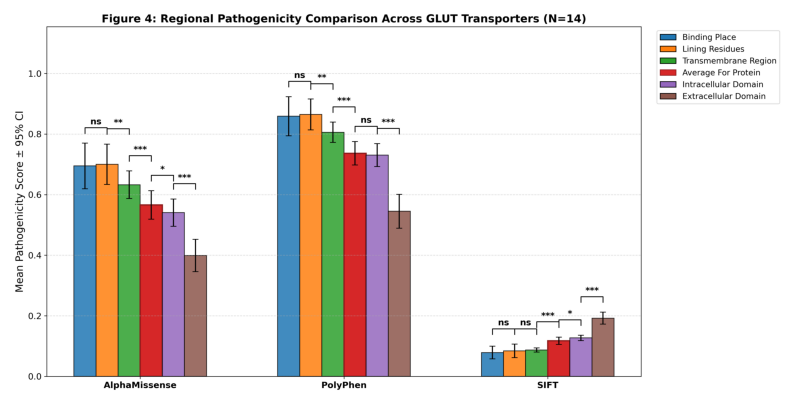

In [13]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = Path.cwd() / 'results/statistics/figure4_region_comparison_bars.png'
img = Image.open(img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()


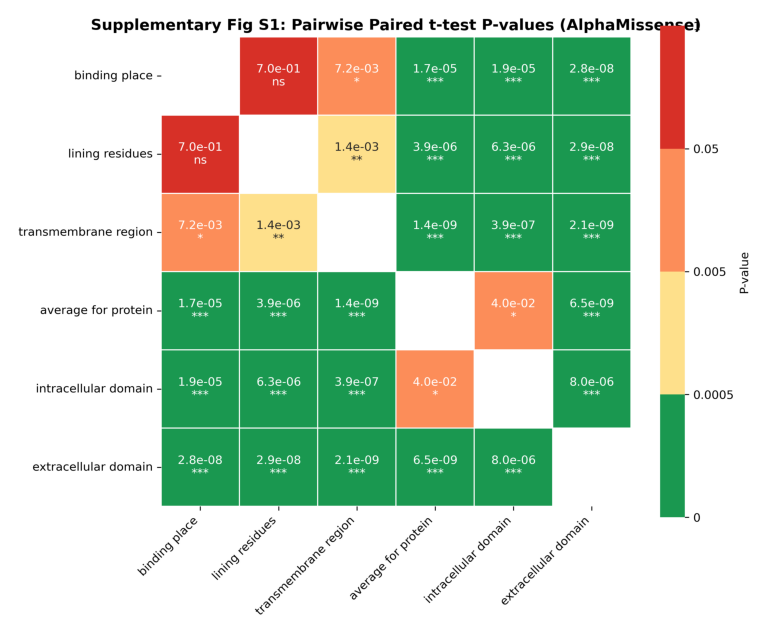

In [14]:
img_path = Path.cwd() / 'results/statistics/pvalue_heatmap_AlphaMissense.png'
img = Image.open(img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.show()